# Introduction au ML — Séance 3 : Un premier modèle de bout en bout

**Cours :** Introduction au ML  
**Université :** UCAD / FST / DMI  
**Enseignant :** Dr. El Hadji Bassirou TOURÉ

***

## Informations étudiant·e (à compléter)

| | |
|---|---|
| **Prénom NOM** | _(compléter)_ |
| **Numéro d'étudiant** | _(compléter)_ |
| **Date** | _(compléter)_ |

***

## Objectif

Les Séances 1-2 ont couvert la **manipulation** des données. Aujourd'hui, **la machine prédit** pour la première fois. En une dizaine de lignes, on entraîne un modèle et on mesure sa qualité. Question concrète : **ce patient va-t-il rester hospitalisé longtemps ?**

Deux idées en ressortent, valables pour *tout* le Machine Learning : le trio **`fit` / `predict` / `score`**, et pourquoi on évalue **sur des données jamais vues**.

**Format :** démonstration (code fourni, à exécuter) puis exercice **« Exercice »**. Exécute les cellules **dans l'ordre**. **Durée : 1h30 à 2h.**

***
# Partie 0 — Mise en place

On charge les outils, on (re)génère **DataSANTÉ-221**, et on fabrique la **cible** à prédire : `sejour_long` vaut 1 si la durée d'hospitalisation dépasse la durée **médiane**, 0 sinon. (On obtient ainsi deux groupes équilibrés.)

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(221)
plt.rcParams['figure.figsize'] = (7, 4)

def generate_datasante221(n=10_000, seed=221):
    rng = np.random.default_rng(seed)
    age = np.clip(rng.gamma(2.5, 14, n), 5, 85).round(0).astype(int)
    glycemie = np.clip(rng.normal(5.5 + 0.05*age, 1.8), 3.0, 18.0).round(1)
    hemoglobine = np.clip(rng.normal(12.5 - 0.02*age, 1.5), 6.0, 17.0).round(1)
    fievre = np.clip(rng.normal(37.5, 0.9, n), 36.0, 41.5).round(1)
    saison = rng.choice([0, 1], size=n, p=[0.55, 0.45])
    duree = (1.0 + 0.05*age + 0.6*glycemie - 0.3*hemoglobine
             + 1.5*saison + rng.normal(0, 1.8, n)).clip(0.5, 30).round(1)
    proba_palu = 1 / (1 + np.exp(-(-3 + 1.5*saison + 0.8*(fievre > 38.5))))
    palu = (rng.uniform(0, 1, n) < proba_palu).astype(int)
    return pd.DataFrame({'age': age, 'glycemie': glycemie, 'hemoglobine': hemoglobine,
                         'fievre': fievre, 'saison': saison,
                         'duree_hospit_j': duree, 'paludisme': palu})

df = generate_datasante221()

seuil = df['duree_hospit_j'].median()
df['sejour_long'] = (df['duree_hospit_j'] > seuil).astype(int)

print(f"Durée médiane : {seuil} jours")
print(df['sejour_long'].value_counts())
df.head()

Durée médiane : 4.1 jours
sejour_long
0    5045
1    4955
Name: count, dtype: int64


,age,glycemie,hemoglobine,fievre,saison,duree_hospit_j,paludisme,sejour_long
0,47,9.3,11.8,38.0,0,3.8,0,0
1,18,5.1,13.0,39.5,1,0.5,0,0
2,56,7.2,9.5,37.1,1,6.5,0,1
3,36,6.8,10.4,36.1,1,5.0,1,1
4,9,6.2,12.0,37.9,0,2.2,0,0


***
# Partie 1 — La tâche : apprendre à partir d'exemples

En apprentissage **supervisé**, on apprend à partir d'**exemples déjà étiquetés**. On distingue :
- les **caractéristiques** `X` (ce qu'on connaît : âge, glycémie, hémoglobine, fièvre, saison) ;
- l'**étiquette** `y` (ce qu'on veut prédire : `sejour_long`).

Le modèle apprend la **relation X → y**, puis sait prédire `y` pour de nouveaux patients.

<div align="center">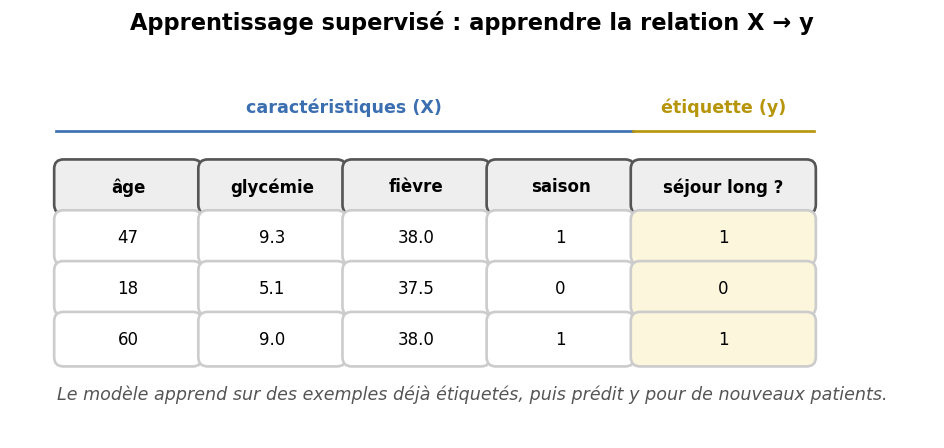</div>


In [2]:
X = df[['age', 'glycemie', 'hemoglobine', 'fievre', 'saison']]   # caractéristiques
y = df['sejour_long']                                            # étiquette à prédire

print("X :", X.shape, "| y :", y.shape)
X.head()

X : (10000, 5) | y : (10000,)


,age,glycemie,hemoglobine,fievre,saison
0,47,9.3,11.8,38.0,0
1,18,5.1,13.0,39.5,1
2,56,7.2,9.5,37.1,1
3,36,6.8,10.4,36.1,1
4,9,6.2,12.0,37.9,0


**En notation.** Les caracteristiques forment une matrice $X\in\mathbb{R}^{n\times d}$ ($n$ exemples, $d$ colonnes) et les etiquettes un vecteur $\mathbf{y}=(y_1,\dots,y_n)$. Le modele est une fonction $f$ telle que $\hat{y}_i = f(\mathbf{x}_i)$. Ici, classification : $y_i \in \{0,1\}$.

**Pont avec le cours — la vraie matrice $X$ et le vecteur $x_1$.** Le cours affiche les premières lignes de $X$ : regardons-les *en vrai*, puis extrayons la première ligne — le vecteur $x_1\in\mathbb{R}^5$ — avec son étiquette $y_1$.

In [3]:
print("X est de taille", X.shape, " (n = 10 000 patients, d = 5 caracteristiques)")
display(X.head(4))   # la vraie matrice : 1 ligne = 1 patient, 1 colonne = 1 caracteristique

x1 = X.values[0]     # premiere ligne de X = le vecteur x_1
print("x_1 =", x1, " -> un point de R^5")
print("y_1 =", y.iloc[0], " (0 = sejour court)")

X est de taille (10000, 5)  (n = 10 000 patients, d = 5 caracteristiques)


,age,glycemie,hemoglobine,fievre,saison
0,47,9.3,11.8,38.0,0
1,18,5.1,13.0,39.5,1
2,56,7.2,9.5,37.1,1
3,36,6.8,10.4,36.1,1


x_1 = [47.   9.3 11.8 38.   0. ]  -> un point de R^5
y_1 = 0  (0 = sejour court)


**Exercice.** La cellule ci-dessus a mis 5 colonnes dans `X`. Créer de la même façon un `X2` qui ne garde que `age` et `glycemie`, puis affiche `X2.head()`.

In [4]:
# À toi : même chose que la cellule précédente, mais garde seulement 'age' et 'glycemie'


***
# Partie 2 — Séparer « réviser » et « examen » : train_test_split

On ne juge pas un·e étudiant·e sur les exercices qu'il a déjà corrigés. Pareil ici : on coupe les données en deux.
- **Train (80 %)** = pour **réviser** : le modèle apprend dessus.
- **Test (20 %)** = pour **l'examen** : on mesure la performance sur des patients **jamais vus**.

`stratify=y` garde la même proportion de séjours longs dans les deux parties ; `random_state` rend la coupe **reproductible**.

<div align="center">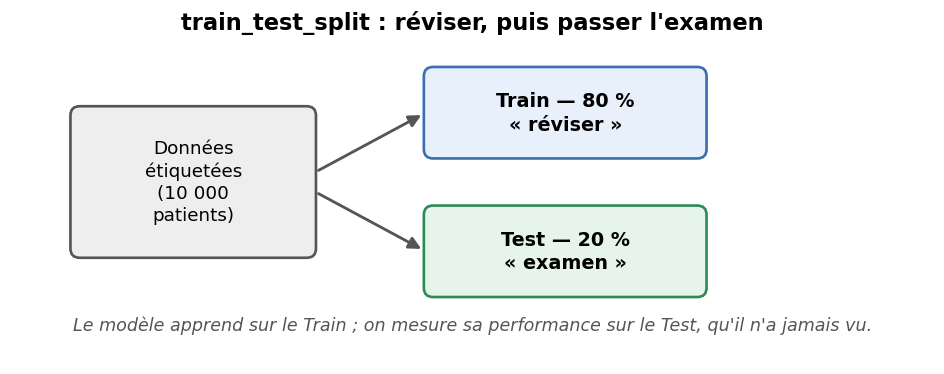</div>


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train :", X_train.shape, "| Test :", X_test.shape)

Train : (8000, 5) | Test : (2000, 5)


**Exercice.** Refaire la même découpe avec `train_test_split`, mais en prenant `test_size=0.3`. Regarde les nouvelles tailles de Train et Test.

In [6]:
# À toi : même train_test_split que ci-dessus, mais avec test_size=0.3


***
# Partie 3 — Un premier modèle en 4 lignes : fit → predict → score

C'est le cœur de la séance. On choisit un modèle (ici un **arbre de décision** : une série de questions oui/non), on l'**entraîne** (`fit`), et on **mesure** sa performance (`score`). 

**On n'a pas besoin de savoir comment l'arbre fonctionne à l'intérieur** : c'est tout l'intérêt de scikit-learn — utiliser d'abord, comprendre ensuite.

<div align="center">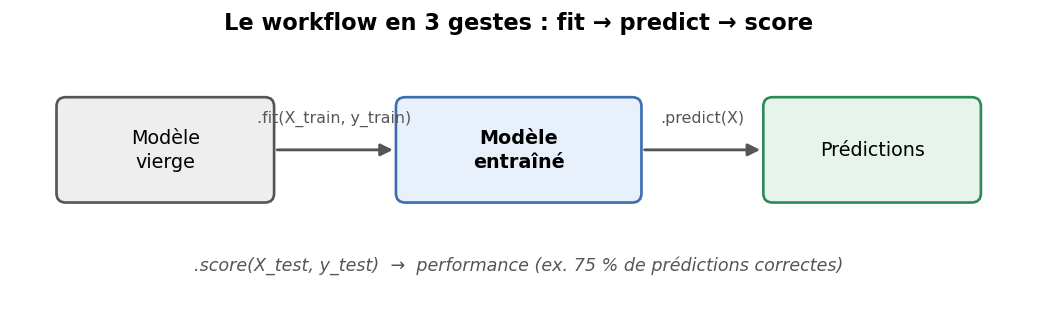</div>


In [7]:
from sklearn.tree import DecisionTreeClassifier

modele = DecisionTreeClassifier(max_depth=4, random_state=0)   # 1. choisir
modele.fit(X_train, y_train)                                   # 2. entraîner
accuracy = modele.score(X_test, y_test)                      # 3. évaluer (sur le test)

print(f"Accuracy sur le test : {accuracy:.1%}")

Accuracy sur le test : 76.5%


**L'exemple du cours — comparer $y$ et $\hat y$.** Le cours compare, composante par composante, le vecteur des réponses et celui des prédictions sur cinq patients. Reproduction du calcul :

In [8]:
y_vrai = np.array([1, 0, 1, 1, 0])     # les reponses
y_hat  = np.array([1, 0, 0, 1, 1])     # les predictions
correct = (y_hat == y_vrai)
print("correcte ?      :", correct)
print(f"accuracy = {correct.mean():.2f}   |   risque = {1 - correct.mean():.2f}")

correcte ?      : [ True  True False  True False]
accuracy = 0.60   |   risque = 0.40


**Pont avec le cours — le risque empirique.** Le cours définit le risque comme la moyenne des pertes 0/1 : $\widehat{R}(f)=\frac{1}{n}\sum_i \mathbf{1}[f(x_i)\neq y_i]$, et l'accuracy comme son complément. Vérification à la main :

In [9]:
y_pred = modele.predict(X_test)
pertes = (y_pred != y_test).astype(int)        # perte 0/1 patient par patient
risque = pertes.mean()                          # moyenne des pertes
print(f"risque empirique  = {risque:.4f}")
print(f"1 - risque        = {1 - risque:.4f}")
print(f"modele.score(...) = {modele.score(X_test, y_test):.4f}   (identiques)")

risque empirique  = 0.2345
1 - risque        = 0.7655
modele.score(...) = 0.7655   (identiques)


**Exercice.** Calculer de la même façon le risque et l'accuracy **sur le jeu d'entraînement** (`X_train`, `y_train`). L'écart entre les deux accuracies est la signature étudiée en fin de séance.

In [10]:
# Exercice : risque et accuracy sur le train


**Accuracy.** Le score d'un classifieur est $\mathrm{acc} = \frac{1}{n}\sum_{i} \mathbf{1}[\hat{y}_i = y_i]$ : la proportion de predictions correctes (l'erreur vaut $1-\mathrm{acc}$).

**Pont avec le cours — vérifier l'accuracy.** Le cours définit $\mathrm{accuracy}=\frac{1}{n}\sum_i \mathbf{1}[\hat y_i = y_i]$ : la proportion de bonnes réponses. Recalculons-la « à la main », et comparons à une **baseline**.

In [11]:
# accuracy a la main = proportion de predictions correctes
y_pred = modele.predict(X_test)
acc_main = (y_pred == y_test).mean()
print(f"Accuracy a la main : {acc_main:.4f}  (score sklearn : {modele.score(X_test, y_test):.4f})")
print(f"Soit {int(acc_main*len(y_test))} bonnes reponses sur {len(y_test)} patients")

# baseline : toujours predire la classe majoritaire
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Baseline (classe majoritaire) : {baseline.score(X_test, y_test):.4f}")

Accuracy a la main : 0.7655  (score sklearn : 0.7655)
Soit 1531 bonnes reponses sur 2000 patients
Baseline (classe majoritaire) : 0.5045


**Ça marche !** Le modèle prédit correctement le séjour pour environ **3 patients sur 4 qu'il n'a jamais vus** — alors que le hasard ferait ~50 %. En quatre lignes, le modèle fonctionne.

**Pont avec le cours — comment l'arbre choisit sa première coupure.** Le cours mesure l'impureté d'un groupe par l'entropie $H=-\sum_k p_k\log_2 p_k$ (ou l'indice de Gini $G=1-\sum_k p_k^2$), et le **gain** d'une coupure $=\;H(\text{parent})-\sum_c \frac{n_c}{n}H(c)$. Vérifions, à la main, la première coupure de notre arbre : `glycemie <= 7.35`.

In [12]:
# impurete d'un noeud (cas binaire), a la main
def entropie(yv):
    p = yv.mean()
    if p in (0.0, 1.0):
        return 0.0
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

def gini(yv):
    p = yv.mean()
    return 1 - p**2 - (1-p)**2

# la 1re coupure de l'arbre : glycemie <= 7.35
gauche = y_train[X_train['glycemie'] <= 7.35]
droite = y_train[X_train['glycemie'] >  7.35]
n, nG, nD = len(y_train), len(gauche), len(droite)

H_parent = entropie(y_train)
gain = H_parent - (nG/n)*entropie(gauche) - (nD/n)*entropie(droite)

print(f"Parent : H = {H_parent:.3f} bit  |  Gini = {gini(y_train):.3f}")
print(f"Gauche (glycemie<=7.35) : {nG} patients, {gauche.mean():.0%} longs, H = {entropie(gauche):.3f}")
print(f"Droite (glycemie> 7.35) : {nD} patients, {droite.mean():.0%} longs, H = {entropie(droite):.3f}")
print(f"Gain d'information      : {gain:.3f} bit")

Parent : H = 1.000 bit  |  Gini = 0.500
Gauche (glycemie<=7.35) : 4190 patients, 28% longs, H = 0.854
Droite (glycemie> 7.35) : 3810 patients, 73% longs, H = 0.836
Gain d'information      : 0.155 bit


**Pont avec le cours — le duel des deux questions, à la main.** Le cours montre que l'arbre choisit sa coupure en comparant les **gains** (et renvoie ici pour le détail). Voici le mini-jeu : **8 patients**, deux questions candidates — `glycemie <= 7` contre `fievre <= 38`. On calcule le gain de chacune avec la fonction `entropie` ci-dessus ; c'est ce duel que l'arbre joue pour **toutes** les coupures possibles (l'argmax du cours).

In [13]:
mini = pd.DataFrame({
    'glycemie':    [5.0, 6.0, 6.5, 7.0, 8.0, 9.0, 10.0, 12.0],
    'fievre':      [37.3, 37.0, 37.6, 38.2, 37.9, 38.5, 39.1, 38.8],
    'sejour_long': [1, 0, 0, 0, 1, 1, 1, 0]})
display(mini)   # le tableau des 8 patients

def gain_question(d, colonne, seuil):
    gauche = d[d[colonne] <= seuil]['sejour_long']
    droite = d[d[colonne] >  seuil]['sejour_long']
    return (entropie(d['sejour_long'])
            - len(gauche)/len(d)*entropie(gauche)
            - len(droite)/len(d)*entropie(droite))

print(f"Question A (glycemie <= 7)  : gain = {gain_question(mini, 'glycemie', 7):.3f} bit   <- comme dans le cours")
print(f"Question B (fievre <= 38)   : gain = {gain_question(mini, 'fievre', 38):.3f} bit   -> n'apprend rien")

,glycemie,fievre,sejour_long
0,5.0,37.3,1
1,6.0,37.0,0
2,6.5,37.6,0
3,7.0,38.2,0
4,8.0,37.9,1
5,9.0,38.5,1
6,10.0,39.1,1
7,12.0,38.8,0


Question A (glycemie <= 7)  : gain = 0.189 bit   <- comme dans le cours
Question B (fievre <= 38)   : gain = 0.000 bit   -> n'apprend rien


**Exercice.** Même appel `gain_question` que ci-dessus, mais avec la question `glycemie <= 9.5`. Que constate-t-on ?

In [14]:
# A toi : meme gain_question que ci-dessus, mais avec 'glycemie' et le seuil 9.5


**Exercice.** Refaire exactement le même calcul de gain, mais pour une coupure sur `saison` (saison == 0 d'un côté, saison == 1 de l'autre). Le gain est-il plus grand ou plus petit que celui de la glycémie ? (C'est ce qui explique pourquoi l'arbre a choisi la glycémie en premier.)

In [15]:
# A toi : meme chose que la cellule precedente, mais coupe sur 'saison' (==0 vs ==1)


**La construction complète, comme dans le cours.** Le cours déroule la construction de l'arbre jusqu'au bout : après la coupure racine `glycemie <= 7`, chaque nœud enfant est purifié à son tour. Vérification des deux gains de l'étape 2 :

In [16]:
noeud_gauche = mini[mini['glycemie'] <= 7]
noeud_droit  = mini[mini['glycemie'] >  7]
print(f"noeud gauche : H = {entropie(noeud_gauche['sejour_long']):.3f}")
print(f"  coupure glycemie <= 5.5 : gain = {gain_question(noeud_gauche, 'glycemie', 5.5):.3f}  (feuilles pures)")
print(f"noeud droit  : H = {entropie(noeud_droit['sejour_long']):.3f}")
print(f"  coupure glycemie <= 11  : gain = {gain_question(noeud_droit, 'glycemie', 11):.3f}  (feuilles pures)")

noeud gauche : H = 0.811
  coupure glycemie <= 5.5 : gain = 0.811  (feuilles pures)
noeud droit  : H = 0.811
  coupure glycemie <= 11  : gain = 0.811  (feuilles pures)


Les deux gains valent **0,811** : tout le désordre restant est absorbé, toutes les feuilles sont pures. Vérification finale : `scikit-learn`, entraîné sur les mêmes huit patients, reproduit exactement cet arbre.

score sur les 8 patients : 1.0


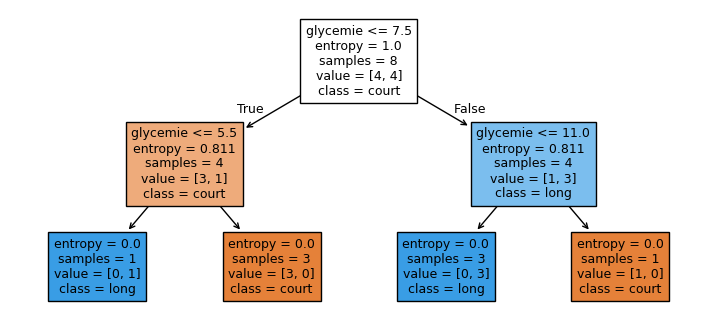

In [17]:
from sklearn.tree import plot_tree
arbre_jouet = DecisionTreeClassifier(criterion='entropy', random_state=0)
arbre_jouet.fit(mini[['glycemie', 'fievre']], mini['sejour_long'])
print("score sur les 8 patients :", arbre_jouet.score(mini[['glycemie','fievre']], mini['sejour_long']))

plt.figure(figsize=(9, 4))
plot_tree(arbre_jouet, feature_names=['glycemie', 'fievre'],
          class_names=['court', 'long'], filled=True, fontsize=9)
plt.show()

**Exercice.** L'arbre obtient 8/8 sur ses propres données d'entraînement, avec des feuilles pures. Au vu de la section sur le sur-apprentissage : ce score parfait est-il une bonne ou une mauvaise nouvelle ? Rédiger la réponse en une phrase dans la cellule ci-dessous.

In [18]:
# Exercice : reponse en commentaire
# ...

**Exercice.** Refaire exactement le même modèle, mais avec `max_depth=6` (puis avec `10`), et compare l'accuracy obtenue sur le test.

In [19]:
# À toi : même modèle que ci-dessus, mais change max_depth (essaie 6, puis 10)


***
# Partie 4 — Prédire pour de nouveaux patients

Une fois entraîné, le modèle prédit avec `.predict(...)`. Les nouveaux patients doivent avoir **les mêmes colonnes**, dans le même ordre.

In [20]:
nouveaux = pd.DataFrame([
    {'age': 60, 'glycemie': 9.0, 'hemoglobine': 10.5, 'fievre': 38.0, 'saison': 1},
    {'age': 25, 'glycemie': 5.0, 'hemoglobine': 14.0, 'fievre': 37.2, 'saison': 0},
])
predictions = modele.predict(nouveaux)   # 1 = séjour long, 0 = court
print(predictions)

[1 0]


**Pont avec le cours — une probabilité, pas un verdict.** L'arbre ne renvoie pas seulement $0/1$ : `predict_proba` donne la **proportion** de chaque classe dans la feuille atteinte. La classe finale vient ensuite d'un **seuil** ($0{,}5$ par défaut).

In [21]:
# proportion de chaque classe dans la feuille (et non un simple 0/1)
modele.predict_proba(nouveaux)
# [[0.05 0.95]]  patient 1 : 95% "long"
# [[0.94 0.06]]  patient 2 : 94% "court"

array([[0.04554865, 0.95445135],
       [0.94427861, 0.05572139]])

**Exercice.** Reprendre le tableau de patients ci-dessus, change les valeurs d'un patient (ou ajoute-en un), puis affiche la prédiction.

In [22]:
# À toi : même chose que ci-dessus, avec un (ou des) patient(s) aux valeurs de ton choix


***
# Partie 5 — Pourquoi évaluer sur des données jamais vues ?

Un·e étudiant·e qui **apprend par cœur** les corrigés aura 20/20 sur ces exercices… mais ratera l'examen sur de nouveaux énoncés. Un modèle peut faire pareil : c'est le **sur-apprentissage** (*overfitting*).

Comparons le score sur le **Train** (réviser) et sur le **Test** (examen).

In [23]:
print(f"Arbre profondeur 4  -> train : {modele.score(X_train, y_train):.1%} "
      f"| test : {modele.score(X_test, y_test):.1%}")

Arbre profondeur 4  -> train : 77.4% | test : 76.5%


**Ecart de generalisation.** On compare les deux erreurs : $\mathrm{err}_{\text{test}} - \mathrm{err}_{\text{train}}$. Un ecart faible = bonne generalisation ; un grand ecart = sur-apprentissage.

Petit écart train/test : le modèle a **compris**, il généralise. Maintenant, laissons un arbre pousser **sans limite** de profondeur.

In [24]:
arbre_profond = DecisionTreeClassifier(max_depth=None, random_state=0).fit(X_train, y_train)
print(f"Arbre profond       -> train : {arbre_profond.score(X_train, y_train):.1%} "
      f"| test : {arbre_profond.score(X_test, y_test):.1%}")

Arbre profond       -> train : 100.0% | test : 70.0%


L'arbre profond atteint **~100 % sur le train** (il a mémorisé chaque patient !) mais fait **moins bien sur le test** que l'arbre simple : il a **appris par cœur** au lieu de comprendre. 

**La leçon centrale :** le seul score qui compte est celui sur des données **jamais vues** (le test). Visualisons-le.

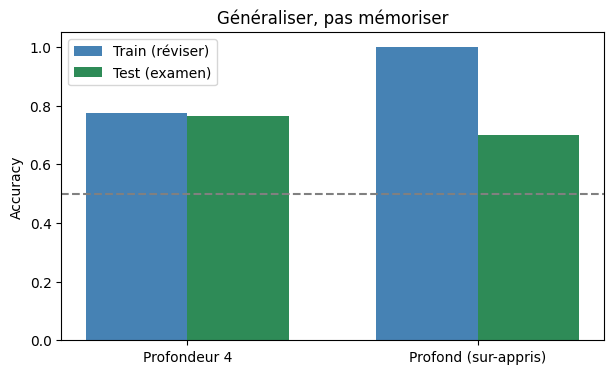

In [25]:
noms = ["Profondeur 4", "Profond (sur-appris)"]
train_acc = [modele.score(X_train, y_train), arbre_profond.score(X_train, y_train)]
test_acc  = [modele.score(X_test,  y_test),  arbre_profond.score(X_test,  y_test)]

x = np.arange(2); w = 0.35
plt.bar(x - w/2, train_acc, w, label="Train (réviser)", color="steelblue")
plt.bar(x + w/2, test_acc,  w, label="Test (examen)",  color="seagreen")
plt.axhline(0.5, ls="--", color="gray")
plt.xticks(x, noms); plt.ylabel("Accuracy"); plt.ylim(0, 1.05)
plt.title("Généraliser, pas mémoriser"); plt.legend()
plt.show()

**Pont avec le cours — la courbe du sur-apprentissage.** Faisons varier la profondeur de 1 à 15 et traçons l'accuracy *train* vs *test*. On doit retrouver la courbe du cours : le train monte toujours, le test culmine puis redescend.

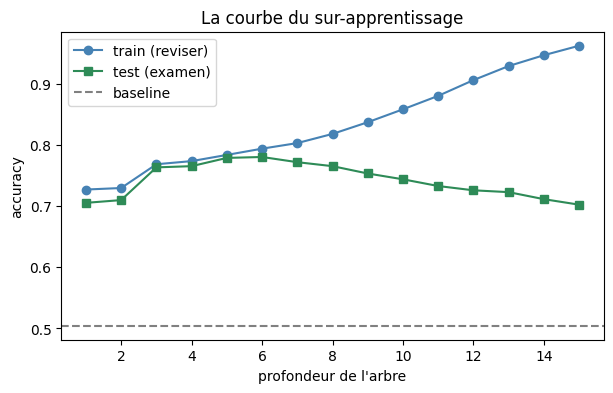

Meilleure profondeur sur le test : 6


In [26]:
profondeurs = range(1, 16)
acc_tr, acc_te = [], []
for d in profondeurs:
    m = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_train, y_train)
    acc_tr.append(m.score(X_train, y_train))
    acc_te.append(m.score(X_test,  y_test))

plt.plot(list(profondeurs), acc_tr, 'o-', color="steelblue", label="train (reviser)")
plt.plot(list(profondeurs), acc_te, 's-', color="seagreen",  label="test (examen)")
plt.axhline(0.5045, ls="--", color="gray", label="baseline")
plt.xlabel("profondeur de l'arbre"); plt.ylabel("accuracy")
plt.title("La courbe du sur-apprentissage"); plt.legend(); plt.show()

meilleur = list(profondeurs)[int(np.argmax(acc_te))]
print(f"Meilleure profondeur sur le test : {meilleur}")

## Synthèse

- [ ] **Tâche supervisée** : on apprend la relation entre des **caractéristiques** `X` et une **étiquette** `y`.
- [ ] **train_test_split** : réviser (train) vs examen (test).
- [ ] Le trio **`fit` / `predict` / `score`** — un modèle en 4 lignes.
- [ ] **`predict`** pour de nouveaux cas (mêmes colonnes).
- [ ] **Sur-apprentissage** : un modèle peut mémoriser le train et rater le test.
- [ ] **Le score qui compte est sur le test** (données jamais vues).

**En une phrase :** _(complète)_ « On mesure un modèle sur des données ... »

## Mini-défi — prédire le paludisme
DataSANTÉ-221 contient une seconde cible : `paludisme` (maladie présente ou non). Le défi : appliquer le protocole complet de la séance à cette nouvelle cible, et confronter le résultat à la baseline.

D'abord, la baseline majoritaire :

In [27]:
y2 = df['paludisme']
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2)
baseline_palu = max(y2_test.mean(), 1 - y2_test.mean())
print(f"prevalence du paludisme : {y2.mean():.1%}")
print(f"baseline majoritaire    : {baseline_palu:.4f}")

prevalence du paludisme : 11.8%
baseline majoritaire    : 0.8825


**Défi.** Entraîner un arbre (profondeur au choix) sur `(X2_train, y2_train)` et calculer son score sur le test. Comparer à la baseline : le modèle fait-il mieux ?

In [28]:
# Defi : arbre sur le paludisme, score test, comparaison a la baseline


**Ce que l'on doit constater.** Quelle que soit la profondeur, l'arbre plafonne autour de $0{,}88$… c'est-à-dire au niveau de la baseline ($0{,}8825$) — et l'arbre profond fait même *moins bien* ($0{,}79$). Sur une maladie **rare** (11,8 % des patients), l'accuracy ne distingue plus un modèle utile d'un modèle paresseux : il faut d'autres métriques. C'est précisément l'objet de la **Séance 6**.

## Pour aller plus loin (optionnel)

Entraîne un arbre pour chaque profondeur de 1 à 15, et trace la **précision sur le test** en fonction de `max_depth`. Que se passe-t-il quand la profondeur devient trop grande ? *(Indice : une boucle `for`, une liste de scores, puis `plt.plot`.)*

Pas de correction ici : c'est une première rencontre avec l'idée des **courbes** qu'on étudiera en Séance 7.